# Spotify Lab: Vectors, Inner Products, and Similar Songs

**Name(s):** Savannah Fox
,Keshav, Paola, Sree, Jake

You are a new data engineer at Spotify.

When a listener asks for songs with similar content, we want to query the library of music and select appropriate recommendations. 

Every song is represented as a vector, and we are using a **vector database**: Each song is encoded as a vector of word counts. So if "love" appears 12 times in the song, the "love" coordinate is $x_{\text{love}}=12$. If Metallica writes songs about topics that are more similar to Black Sabbath than to Josh Groban, then the vector representations of their songs will have more similar profiles, and we should suggest Black Sabbath over Josh Groban. This approach is fundamental to technologies like LLMs or facial recognition, which store documents and faces as vectors and conducts fast look-ups using the kinds of math we'll look at in this lab.

The main data, `song_vectors.csv.gz`, include:

- `track_id`, `song_id`, `artist_id`: Internal unique track identifiers
- `artist_name`, `song_title`, `release`: Artist, song, album
- `release_year`, `duration`: `
- `artist_familiarity`, `artist_hotttnesss`: Measures of ubiquity, popularity
- `genre`, `top_tags`: Information about the song type
- `n_words`, `nnz_words`, `l2_norm`: Number of total words in the song, number of non-zero word coordinates (i.e. number of unique words), and the word counts squared/summed/square-rooted.
- `is_test`: Train-test split identification
- 800 columns of word counts

The `top_40_songs_by_genre.csv` file contains the top 40 songs by genre -- rock, metal, pop, punk, country, r&b/soul, folk, hip hop, electronic, blues, jazz, reggae, latin, classical -- by "hotttness". We'll use these songs to benchmark.

The `vocabulary.csv` file includes the 800 words that form the vector space in which the songs are modeled.

Each song becomes a vector of lyric-word counts, and then we use vector operations to quantify "similarity".

The big goal of this lab is simple:

**Vectors and inner products and vector length are the core tools of modern retrieval systems.**

## Setup

We will use:

- `./data/song_vectors.csv.gz`: one row per song
- `./data/vocabulary.csv`: the word columns used in the song vectors

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


songs = pd.read_csv( "./data/song_vectors.csv.gz" )
vocab = pd.read_csv( "./data/vocabulary.csv" )
top_40 = pd.read_csv("./data/top_40_songs_by_genre.csv")

word_cols = vocab["word"].tolist() # Song count matrix
meta_cols = songs.columns.drop(word_cols).tolist() # Information about tracks

print('Number of songs, number of words:', songs.shape)
print( 'Song metadata fields:', meta_cols[:8])

Number of songs, number of words: (8000, 816)
Song metadata fields: ['track_id', 'song_id', 'artist_id', 'artist_name', 'song_title', 'release', 'release_year', 'duration']


In [2]:
songs[meta_cols].head()

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0
1,TRAAWOR128F92DF3C8,SOBJYXZ12A8AE45FF1,ARY80281187FB3E380,Sandi Thom,Wounded Hearts,The Pink & The Lily,2008,205.21751,0.655359,0.405031,blues,blues,287,103,39.698866,0
2,TRABNZS128F932C6E8,SOCOZZE12A813568F7,AROWOZ41187FB5B535,G. Love & Special Sauce,Willow Tree,Yeah_ It's That Easy,1997,206.57587,0.717235,0.548694,blues,blues; chill; alternative; rock; jazz,211,64,33.090784,0
3,TRABOIH128F9300B06,SOHYOTB12AF72AA1D7,AR94ZOI1187FB46BDA,Willie Dixon,That's My Baby,Very Best Of The Blues,1989,208.90077,0.579533,0.429834,blues,delta blues; BLUEZZZ; blues; freedom; Willie D...,164,76,27.477263,0
4,TRABYAR128F931B1A4,SOVKUOE12A58A8066E,AR7BMMV1187FB5B2D7,Robben Ford,Something For The Pain,Blue Moon,2002,298.37016,0.604820,0.383877,blues,blues; Robben Ford; vinnie colaiuta; jimmy earl,187,75,27.604347,0


## Part 1: Similarity Measures for Song Vectors

The word-count columns are coordinates. That means each song is a vector in a high-dimensional space.

We will work with the song-by-word matrix $X$, where each row is one song vector.

In [2]:
X = songs[word_cols].to_numpy(dtype=float)

query_idx = 0 # Let's query the first song
query = X[query_idx]

print( 'Track metadata: \n')
print(songs.loc[query_idx, meta_cols])

print( 'Track word counts: \n')
print( query )

Track metadata: 

track_id                                            TRAAPIV128F1493132
song_id                                             SOJHKYL12A6D4FA0AC
artist_id                                           AR56P361187B9AC4DB
artist_name                                                 Gary Moore
song_title                                        What Are We Here For
release                                          Dark Days In Paradise
release_year                                                      1997
duration                                                     345.93914
artist_familiarity                                            0.761362
artist_hotttnesss                                             0.467111
genre                                                            blues
top_tags              blues; classic rock; rock; hard rock; blues rock
n_words                                                            218
nnz_words                                                  

In [3]:
# Let's see the counts for nonzero words

nonzero = np.flatnonzero(query)

pd.DataFrame({
    "word": np.array(word_cols)[nonzero],
    "count": query[nonzero].astype(int),
}).sort_values("count", ascending=False).head(15)

,word,count
62,we,27
4,are,10
17,for,9
37,of,7
63,what,6
26,it,6
21,here,6
20,have,6
41,our,5
54,through,5


## Step 1: Dot Product

The dot product is our first similarity score:

$$
x \cdot y = \sum_{j=1}^m x_j y_j
$$

It gets large when two songs align count mass on the same words. 

It also tends to go up for longer songs or songs with larger total counts, which is a choice we'll have to think about.

In [3]:
# Compute the dot product between every song vector and the query vector.
dot_scores = X @ query

dot_results = songs[meta_cols].copy()
dot_results["dot"] = dot_scores
dot_results.sort_values("dot", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,dot
1582,TRFSCLD12903CD213F,SOENGNL12AB018E1BD,AR4L4WQ1187FB51996,The Prodigy,We Gonna Rock,What Evil Lurks,1991,282.30485,0.638614,0.601436,electronic,Rave; big beat; jungle; electronic; techno,312,10,141.703917,0,2136.0
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,2115.0
5601,TRCETEN128F42AD6D0,SOXSRBF12D021B1340,AR4KTMS1187B9B4873,Bowling For Soup,Here We Go,Goes To The Movies,2004,188.36853,0.790406,0.561934,punk,pop punk; The Good Stuff; Bowling For Soup; pr...,374,92,98.863542,0,1939.0
1930,TRWAMJL128F92D124B,SOUSJHY12A8C1457F0,ARQ85IK11C8A415C6A,Ladyhawke,Crazy World,Ladyhawke,2008,214.93506,0.692569,0.554471,electronic,electropop; indie; female vocalists; electroni...,340,58,74.229374,0,1680.0
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,1656.0
3053,TRTCOWO128F930C444,SONWWDY12A6D4F7FB1,ARIHE7O1187FB47DED,The Streets,Weak Become Heroes,Summer Sessions,0,494.54975,0.772909,0.527872,hip hop,british; Hip-Hop; garage; 00s; hip hop,754,262,96.337947,0,1654.0
2971,TRPDBLM128E0792367,SOZRPOY12A8C1455F5,ARTDQRC1187FB4EFD4,Black Eyed Peas,Communication,Behind The Front,1998,344.00608,0.845602,1.005942,hip hop,Hip-Hop; funk; dance; communication; heisse sc...,592,173,80.068720,0,1615.0
2874,TRKRVKD128F9327008,SOXKVEZ12AB01821F5,ARX94AN1187FB4B54B,Hollywood Undead,Undead,Desperate Measures,2008,288.07791,0.703476,0.576626,hip hop,rapcore; hollywood undead; rap metal; rock; un...,831,222,97.082439,0,1476.0
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1397.0
5840,TRMGOLR128F933A7DB,SOYDERO12A6D4F72BC,ARZWK2R1187B98F09F,Rise Against,Survive,The Sufferer & The Witness,2006,221.46567,0.847082,0.625080,punk,punk rock; melodic hardcore; punk; rock; Rise ...,324,85,56.169387,0,1383.0


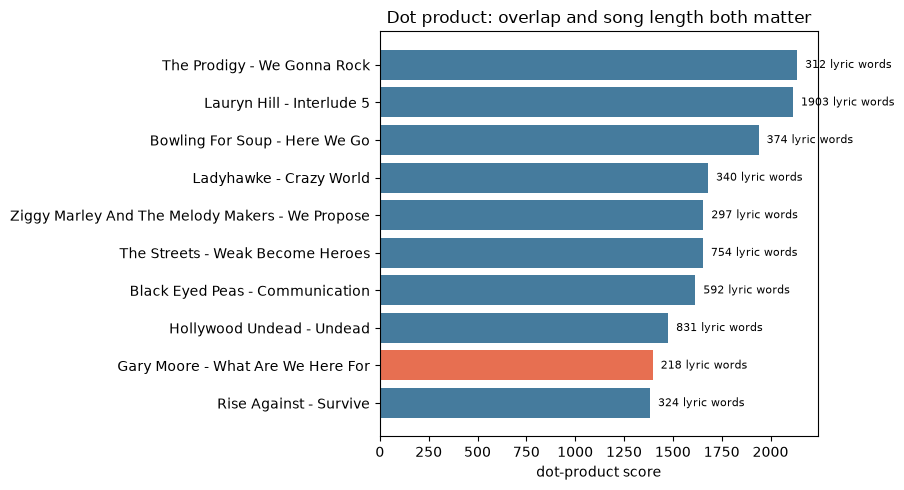

In [16]:
# Visual check: long songs can receive larger dot products.
top_dot = dot_results.sort_values("dot", ascending=False).head(10).copy()
top_dot["label"] = (
    top_dot["artist_name"].fillna("") + " - " + top_dot["song_title"].fillna("")
)
colors = ["#e76f51" if index == query_idx else "#457b9d" for index in top_dot.index]
plt.figure(figsize=(9, 5))
plt.barh(top_dot["label"], top_dot["dot"], color=colors)
for position, words in enumerate(top_dot["n_words"]):
    plt.text(top_dot["dot"].iloc[position], position, f"  {words:.0f} lyric words", va="center", fontsize=8)
plt.gca().invert_yaxis()
plt.xlabel("dot-product score")
plt.title("Dot product: overlap and song length both matter")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Look at the top matches. Do they seem similar because they use similar words, because they are genuinely similar songs, or because the dot product is partly rewarding song size?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the raw inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

They seem similar because they have similar words because we are comparing the individual words in the lyrics of each song. The dot product is also partly reward song length. For example Lauryn Hills "Interlude 5" has 1903 words which allows it to have a higiher number of word matches to other songs and be ranked more similar.

In [17]:
top_40.head()

,track_id,song_id,artist_id,artist_name,song_title,genre
0,TRVYEUW128F148C08D,SOFCCWD12AF72A6BC0,ARXPPEY1187FB51DF4,Michael Jackson,All The Things You Are,blues
1,TRCXKPC128F92FD04C,SOEFNXT12AB017E829,ARZENOX1187B98A645,John Mayer,Vultures,blues
2,TRMMALW128F92FD049,SOVUCRS12A58A7D207,ARZENOX1187B98A645,John Mayer,Out Of My Mind,blues
3,TRJWAJC128F9327C4F,SORMDVX12AB01816AA,ARLMXEA1187B9A7D04,R. Kelly,Hump Bounce,blues
4,TRPEBTH128F9327C4D,SOYTJAC12AF729F49D,ARLMXEA1187B9A7D04,R. Kelly,Intro - The Sermon,blues


Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the raw inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".


In [4]:
top3_matches = []

for i in top_40['track_id']:
    query_idx_t40= songs.index[songs["track_id"]==i][0]
    query_t40=X[query_idx_t40]

    dot_scores = X @ query_t40
    dot_results=songs[meta_cols].copy()
    dot_results['dot']=dot_scores
    dot_results.loc[query_idx_t40,'dot']=-np.inf

    top3=dot_results.sort_values('dot',ascending=False).head(3).copy()
    top3['query_track_id'] = i  
    top3['query_artist']=songs.loc[query_idx_t40,'artist_name']
    top3['query_song']=songs.loc[query_idx_t40,'song_title']
    top3_matches.append(top3)

results= pd.concat(top3_matches, ignore_index=True)
results.to_csv("./data/top_40_songs_by_genre_results.csv",index=False)


results




,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,dot,query_track_id,query_artist,query_song
0,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,3570.0,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are
1,TRWSYHO128F4282346,SOKHOQG12A8C13EBF2,ARSE5NP1187B9B98AB,Twista,I'm A Winner (Amended Album Version),The Day After,2005,260.23138,0.889614,0.593808,hip hop,rap; Hip-Hop; winner in bed twista,1253,166,218.622963,0,2865.0,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are
2,TRVDAHO128F92F231E,SOXUSKK12A8C144F94,AR0IVTL1187B9AD520,Katy Perry,Hot N Cold (Innerpartysystem Main),Hot N Cold,2008,278.30812,0.929487,0.848826,electronic,trance; electronic; dance; female vocalists,429,84,103.841225,0,2436.0,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are
3,TRDPGXU128F9339C2A,SOELYON12AB01876A3,ARLHO5Z1187FB4C861,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Paul's Boutique (20th Anniversary Remastered E...,0,105.56036,0.853125,0.591628,hip hop,hip hop; leapsandbounds CDCollection,1746,505,153.652205,0,3132.0,TRCXKPC128F92FD04C,John Mayer,Vultures
4,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,3012.0,TRCXKPC128F92FD04C,John Mayer,Vultures
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1675,TRGUCIR128F933D817,SORMTGC12A6D4F6C8B,ARQUN9K1187B9B5BD7,Vanilla Ice,Ice Is Workin' It,To The Extreme,1990,275.43465,0.722075,0.463037,hip hop,rap; hiphop; 90s; cool as ice; leapsandbounds ...,898,242,166.246804,0,4137.0,TRCURQD128F427C75B,Hawk Nelson,Turn It On
1676,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,3732.0,TRCURQD128F427C75B,Hawk Nelson,Turn It On
1677,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,5348.0,TRRKJGZ128F148128F,Hawk Nelson,Something On My Mind
1678,TRDPGXU128F9339C2A,SOELYON12AB01876A3,ARLHO5Z1187FB4C861,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Paul's Boutique (20th Anniversary Remastered E...,0,105.56036,0.853125,0.591628,hip hop,hip hop; leapsandbounds CDCollection,1746,505,153.652205,0,5240.0,TRRKJGZ128F148128F,Hawk Nelson,Something On My Mind


## Step 2: Centering and Covariance

Now we subtract each vector's own mean. This changes the question from "Do these songs use many of the same words?" to something closer to "Do these songs rise above and below their own average on the same words?"

In [5]:
query_centered = query - query.mean()
X_centered = X - X.mean(axis=1, keepdims=True)

centered_dot_scores = X_centered @ query_centered
covariance_scores = centered_dot_scores / X.shape[1]

cov_results = songs[meta_cols].copy()
cov_results["centered_dot"] = centered_dot_scores
cov_results["covariance"] = covariance_scores
cov_results.sort_values("covariance", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,centered_dot,covariance
1582,TRFSCLD12903CD213F,SOENGNL12AB018E1BD,AR4L4WQ1187FB51996,The Prodigy,We Gonna Rock,What Evil Lurks,1991,282.30485,0.638614,0.601436,electronic,Rave; big beat; jungle; electronic; techno,312,10,141.703917,0,2064.18000,2.580225
5601,TRCETEN128F42AD6D0,SOXSRBF12D021B1340,AR4KTMS1187B9B4873,Bowling For Soup,Here We Go,Goes To The Movies,2004,188.36853,0.790406,0.561934,punk,pop punk; The Good Stuff; Bowling For Soup; pr...,374,92,98.863542,0,1856.78500,2.320981
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,1767.24000,2.209050
1930,TRWAMJL128F92D124B,SOUSJHY12A8C1457F0,ARQ85IK11C8A415C6A,Ladyhawke,Crazy World,Ladyhawke,2008,214.93506,0.692569,0.554471,electronic,electropop; indie; female vocalists; electroni...,340,58,74.229374,0,1617.63000,2.022038
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,1599.53625,1.999420
3053,TRTCOWO128F930C444,SONWWDY12A6D4F7FB1,ARIHE7O1187FB47DED,The Streets,Weak Become Heroes,Summer Sessions,0,494.54975,0.772909,0.527872,hip hop,british; Hip-Hop; garage; 00s; hip hop,754,262,96.337947,0,1516.73875,1.895923
2971,TRPDBLM128E0792367,SOZRPOY12A8C1455F5,ARTDQRC1187FB4EFD4,Black Eyed Peas,Communication,Behind The Front,1998,344.00608,0.845602,1.005942,hip hop,Hip-Hop; funk; dance; communication; heisse sc...,592,173,80.068720,0,1510.34125,1.887927
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1352.34875,1.690436
5840,TRMGOLR128F933A7DB,SOYDERO12A6D4F72BC,ARZWK2R1187B98F09F,Rise Against,Survive,The Sufferer & The Witness,2006,221.46567,0.847082,0.625080,punk,punk rock; melodic hardcore; punk; rock; Rise ...,324,85,56.169387,0,1313.77875,1.642223
2874,TRKRVKD128F9327008,SOXKVEZ12AB01821F5,ARX94AN1187FB4B54B,Hollywood Undead,Undead,Desperate Measures,2008,288.07791,0.703476,0.576626,hip hop,rapcore; hollywood undead; rap metal; rock; un...,831,222,97.082439,0,1312.27875,1.640348


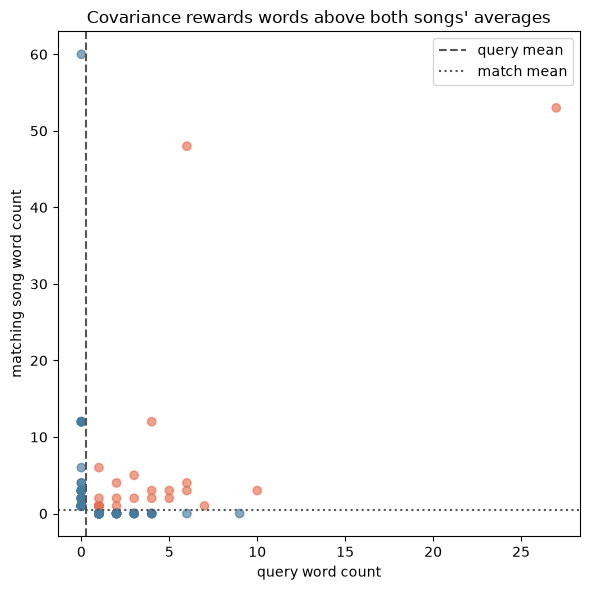

In [9]:
# Visual check: centering moves each song's average word count to zero.
comparison_idx = np.argsort(covariance_scores)[-2]
comparison = X[comparison_idx]
used_words = (query > 0) | (comparison > 0)
both_above_average = (query > query.mean()) & (comparison > comparison.mean())
plt.figure(figsize=(6, 6))
plt.scatter(query[used_words], comparison[used_words],
            c=np.where(both_above_average[used_words], "#e76f51", "#457b9d"), alpha=0.65)
plt.axvline(query.mean(), color="#555555", linestyle="--", label="query mean")
plt.axhline(comparison.mean(), color="#555555", linestyle=":", label="match mean")
plt.xlabel("query word count")
plt.ylabel("matching song word count")
plt.title("Covariance rewards words above both songs' averages")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Compare the rankings from dot product and covariance. What changed? Why does subtracting the mean change the notion of similarity?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the centered inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

Lauryn Hill Intrelude five fell from being the number one match. Subtracting the mean changes the notion of similarity because now the words of a song are no longer weighted by how often they are used but how often they are used relative to the number of times all the other words in the song are used. 

In [6]:
part1 = pd.read_csv("./data/top_40_songs_by_genre_results.csv")
top_three_matches = []

for i in top_40['track_id']:
    query_idx_t40 = songs.index[songs["track_id"] == i][0]
    query_t40 = X[query_idx_t40]

    X_centered = X - X.mean(axis=1, keepdims=True)
    query_t40_centered = query_t40 - query_t40.mean()

    centered_dot_scores = X_centered @ query_t40_centered
    covariance_scores = centered_dot_scores / X.shape[1]
    covariance_scores[query_idx_t40] = -np.inf
    candidates = part1.loc[part1['query_track_id'] == i, 'track_id']
    for track_id in candidates:
        candidate_idx = songs.index[songs['track_id'] == track_id][0]
        top_three_matches.append({
            'query_track_id': i,
            'track_id': track_id,
            'centered_dot': centered_dot_scores[candidate_idx],
            'covariance': covariance_scores[candidate_idx],
        })

top_three_matches_df = pd.DataFrame(top_three_matches)
#top_three_matches_df.sort_values(["covariance"], ascending=False)
part1 = pd.read_csv("./data/top_40_songs_by_genre_results.csv")

combined = pd.merge(part1, top_three_matches_df, on=["query_track_id", "track_id"], how="left")
combined.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)
combined = combined.sort_values(["query_track_id", 'covariance'],ascending=[True, False])
combined


,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,...,n_words,nnz_words,l2_norm,is_test,dot,query_track_id,query_artist,query_song,centered_dot,covariance
1308,TRFGJLT128F1491125,SOODSDC12A6D4F697F,ARPANXO1187B9B468A,Public Enemy,Go Cat Go,He Got Game,1998,228.04853,0.735030,0.473501,...,529,175,105.033328,0,982.0,TRABGYE128E078278A,Wire,Strange,937.36000,1.171700
1309,TRDPGXU128F9339C2A,SOELYON12AB01876A3,ARLHO5Z1187FB4C861,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Paul's Boutique (20th Anniversary Remastered E...,0,105.56036,0.853125,0.591628,...,1746,505,153.652205,0,882.0,TRABGYE128E078278A,Wire,Strange,734.28000,0.917850
1310,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,...,1903,409,215.044182,0,831.0,TRABGYE128E078278A,Wire,Strange,654.36000,0.817950
1446,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,...,1903,409,215.044182,0,2779.0,TRACTLX128F42A51F6,Matisyahu,Exaltation,2409.16000,3.011450
1447,TRDPGXU128F9339C2A,SOELYON12AB01876A3,ARLHO5Z1187FB4C861,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Paul's Boutique (20th Anniversary Remastered E...,0,105.56036,0.853125,0.591628,...,1746,505,153.652205,0,2489.0,TRACTLX128F42A51F6,Matisyahu,Exaltation,2179.71125,2.724639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
571,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,...,1903,409,215.044182,0,2386.0,TRZUSDI128F4259806,Ryan Adams,When The Stars Go Blue,2148.64000,2.685800
572,TREBGAA128E078FC52,SOVYGAV12A58A7C3A9,AR24DZB1187FB3C869,Erykah Badu,I Want You,Worldwide Underground,2003,653.13914,0.855732,0.584842,...,617,98,153.163312,0,2034.0,TRZUSDI128F4259806,Ryan Adams,When The Stars Go Blue,1946.76375,2.433455
1254,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,...,1903,409,215.044182,0,6817.0,TRZVPFY128F92E19DF,The Offspring,Staring At The Sun,6195.08000,7.743850
1255,TRWSYHO128F4282346,SOKHOQG12A8C13EBF2,ARSE5NP1187B9B98AB,Twista,I'm A Winner (Amended Album Version),The Day After,2005,260.23138,0.889614,0.593808,...,1253,166,218.622963,0,6499.0,TRZVPFY128F92E19DF,The Offspring,Staring At The Sun,6092.55500,7.615694


In [11]:
len(top3_matches)

560

## Step 3: Correlation

Correlation takes covariance and rescales by each vector's standard deviation. That means we now compare shared pattern after accounting for both average level and spread.

In [7]:
query_std = query.std()
X_std = X.std(axis=1)

denom = X_std * query_std
corr_scores = np.divide(
    covariance_scores,
    denom,
    out=np.zeros_like(covariance_scores),
    where=denom != 0,
)

corr_results = songs[meta_cols].copy()
corr_results["correlation"] = corr_scores
corr_results.sort_values("correlation", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,correlation
7779,TRQXNHC12903CD80BA,SOFKHCP12A8AE460AF,ARV4GYZ1187B9B8171,Violent Femmes,Add It Up,Permanent Record: The Very Best Of The Violent...,1983,284.34240,0.699073,0.522720,rock,alternative; 80s; rock; punk; indie,479,145,60.745370,0,0.958245
2815,TRISBQQ128F93217A2,SOSKAYL12AB01884DE,ARPXABO1187FB4D15F,2Pac,Strictly 4 My N.I.G.G.A.Z.,Strictly 4 My N.I.G.G.A.Z.,0,355.47383,0.873187,0.517256,hip hop,Hip-Hop; hardcore rap; west coast hip-hop; lea...,921,288,104.316825,0,0.955871
7358,TRBCRNY128F931D755,SOZHKRD12AB0185D84,ARKXXO11187FB4D9D9,Bad Cash Quartet,Valentine,Midnight Prayer,2003,175.62077,0.560999,0.399430,rock,indie; swedish; indie pop; indie rock; vocal,157,68,24.879711,0,0.942267
3129,TRWUNDW128F147093F,SOFZLVC12A6D4F9068,ARNHMFD1187FB3B3F6,LL Cool J,I Can't Live Without My Radio,Radio,1985,331.88526,0.749218,0.544322,hip hop,Hip-Hop; rap; 80s; LL Cool J; hip hop,745,248,81.829090,0,0.940242
2809,TRILLIR128F429E5D7,SOGGIPC12A8C142CD5,AR6F6I21187FB5A3AA,Aesop Rock,Battery,Labor Days,2001,307.04281,0.834539,0.477311,hip hop,Hip-Hop; underground hip-hop; rap; hip hop; De...,617,294,50.547008,0,0.939918
3112,TRWFXWM128F148D2D1,SORSMQE12A58A7A5FE,ARSQSCB1187B9912A0,Warren G,We Brings Heat,Take A Look Over Your Shoulder (Reality),1997,226.92526,0.718017,0.511683,hip hop,chillout; classic; hip hop; cool; Hip-Hop,548,238,50.517324,0,0.935089
3065,TRTMQWK128F4241384,SOIPJHX12A8C1324A3,ARSUQ9F1187B990561,Kottonmouth Kings,Bump,Greatest Highs,1998,232.51546,0.680868,0.563168,hip hop,Hip-Hop; stoned; BUMP; rapcore; kmk,795,259,74.276510,0,0.918332
2841,TRJPNAE128F425FAFB,SOZVCKM12A8C138484,ARRQWQW1187FB49844,King Tee,Act A Fool,Act A Fool,1988,258.82077,0.495739,0.372392,hip hop,Hip-Hop; rap; hip hop; West Coast Rap; west co...,624,251,66.730802,0,0.916275
7974,TRZCHKB128F92CB740,SOFCVMN12A8C141F62,AR4RBOB1187B9AC209,Anastacia,Club Megamix,Pieces Of A Dream,0,708.72771,0.583809,0.323554,rock,Slow Rock; pop; dance; party; female vocalist,749,201,98.020406,0,0.915354
4656,TRNMSBG128F422A877,SODFTRX12A6D4FBBFE,ARV8T9T1187B99F3F4,Amorphis,Weaving The Incantation,Silent Waters,2007,297.19465,0.709011,0.553566,metal,Melodic Death Metal; death metal; Progressive ...,140,77,19.646883,0,0.908918


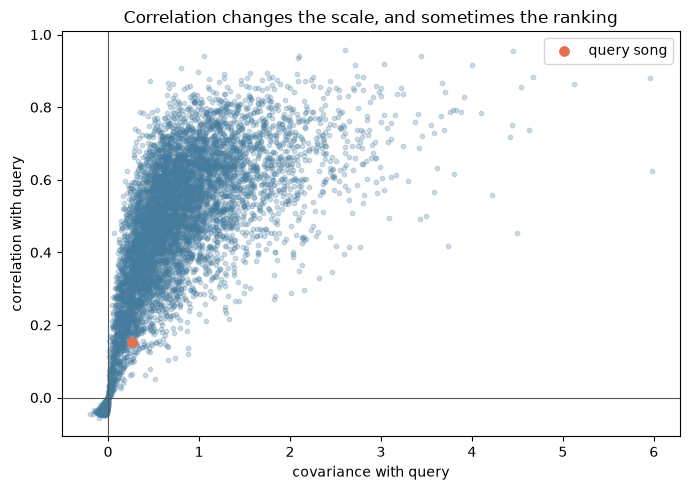

In [10]:
# Visual check: correlation rescales covariance by each song's spread.
plt.figure(figsize=(7, 5))
plt.scatter(covariance_scores, corr_scores, s=10, alpha=0.25, color="#457b9d")
plt.axhline(0, color="#555555", linewidth=0.8)
plt.axvline(0, color="#555555", linewidth=0.8)
plt.scatter(covariance_scores[query_idx], corr_scores[query_idx], color="#e76f51", s=45, label="query song")
plt.xlabel("covariance with query")
plt.ylabel("correlation with query")
plt.title("Correlation changes the scale, and sometimes the ranking")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Correlation and covariance are related, but not identical. What kind of song might move up in the ranking after standardization? What kind might move down?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the correlation. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

Songs that have use the same word a relatively similar number of times might move up in the ranking while songs that that are long and use a lot of word might go down. This is because the correlation helps correct for matches by corvariance caused by song length and repitition.

In [8]:
part2 = pd.read_csv("./data/top_40_songs_by_genre_results.csv")
top_three_matches = []

for i in top_40['track_id']:
    query_idx_t40 = songs.index[songs["track_id"] == i][0]
    query_t40 = X[query_idx_t40]

    X_std = X.std(axis=1)
    #query_t40_centered = query_t40 - query_t40.mean()
    query_t40_std = query_t40.std()

    #centered_dot_scores = X_centered @ query_t40_centered
    covariance_scores = centered_dot_scores / X.shape[1]
    query_t40_std = X_std[query_idx_t40]   # <-- pull from the array you already have, instead of recomputing
    denom = X_std * query_t40_std
    corr_scores = np.divide(
        covariance_scores,
        denom,
        out=np.zeros_like(covariance_scores),
        where=denom != 0,
    )
    corr_scores[query_idx_t40] = -np.inf
    candidates = part1.loc[part1['query_track_id'] == i, 'track_id']
    for track_id in candidates:
        candidate_idx = songs.index[songs['track_id'] == track_id][0]
        top_three_matches.append({
            'query_track_id': i,
            'track_id': track_id,
            'correlation': corr_scores[candidate_idx],
        })


top_three_matches_df = pd.DataFrame(top_three_matches)
#top_three_matches_df.sort_values(["correlation"], ascending=False)
part2 = pd.read_csv("./data/top_40_songs_by_genre_results.csv")

combined = pd.merge(part2, top_three_matches_df, on=['query_track_id',  'track_id'], how="left")
combined.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)
combined = combined.sort_values(["query_track_id","correlation"], ascending=[True, False]) 

combined



,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,...,nnz_words,l2_norm,is_test,dot,query_track_id,query_artist,query_song,centered_dot,covariance,correlation
1309,TRDPGXU128F9339C2A,SOELYON12AB01876A3,ARLHO5Z1187FB4C861,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Paul's Boutique (20th Anniversary Remastered E...,0,105.56036,0.853125,0.591628,...,505,153.652205,0,882.0,TRABGYE128E078278A,Wire,Strange,734.28000,0.917850,1.404713
1310,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,...,409,215.044182,0,831.0,TRABGYE128E078278A,Wire,Strange,654.36000,0.817950,0.995302
1308,TRFGJLT128F1491125,SOODSDC12A6D4F697F,ARPANXO1187B9B468A,Public Enemy,Go Cat Go,He Got Game,1998,228.04853,0.735030,0.473501,...,175,105.033328,0,982.0,TRABGYE128E078278A,Wire,Strange,937.36000,1.171700,0.220509
1447,TRDPGXU128F9339C2A,SOELYON12AB01876A3,ARLHO5Z1187FB4C861,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Paul's Boutique (20th Anniversary Remastered E...,0,105.56036,0.853125,0.591628,...,505,153.652205,0,2489.0,TRACTLX128F42A51F6,Matisyahu,Exaltation,2179.71125,2.724639,0.923823
1446,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,...,409,215.044182,0,2779.0,TRACTLX128F42A51F6,Matisyahu,Exaltation,2409.16000,3.011450,0.654570
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
572,TREBGAA128E078FC52,SOVYGAV12A58A7C3A9,AR24DZB1187FB3C869,Erykah Badu,I Want You,Worldwide Underground,2003,653.13914,0.855732,0.584842,...,98,153.163312,0,2034.0,TRZUSDI128F4259806,Ryan Adams,When The Stars Go Blue,1946.76375,2.433455,0.509502
570,TRWSYHO128F4282346,SOKHOQG12A8C13EBF2,ARSE5NP1187B9B98AB,Twista,I'm A Winner (Amended Album Version),The Day After,2005,260.23138,0.889614,0.593808,...,166,218.622963,0,2749.0,TRZUSDI128F4259806,Ryan Adams,When The Stars Go Blue,2593.87750,3.242347,0.469276
1256,TRDPGXU128F9339C2A,SOELYON12AB01876A3,ARLHO5Z1187FB4C861,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Paul's Boutique (20th Anniversary Remastered E...,0,105.56036,0.853125,0.591628,...,505,153.652205,0,5836.0,TRZVPFY128F92E19DF,The Offspring,Staring At The Sun,5315.90250,6.644878,0.551368
1254,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,...,409,215.044182,0,6817.0,TRZVPFY128F92E19DF,The Offspring,Staring At The Sun,6195.08000,7.743850,0.390669


## Step 4: Cosine Similarity

Cosine similarity compares the raw vectors without centering around their means:

$$
\cos(\theta) = \frac{x \cdot y}{\|x\|\|y\|}
$$

In retrieval systems, this is often a better measure of content similarity than the raw dot product.

In [9]:
def cosine_scores(matrix, query_vector):
    numerators = matrix @ query_vector
    matrix_norms = np.linalg.norm(matrix, axis=1)
    query_norm = np.linalg.norm(query_vector)
    denominators = matrix_norms * query_norm
    return np.divide(
        numerators,
        denominators,
        out=np.zeros_like(numerators),
        where=denominators != 0,
    )


cos_scores = cosine_scores(X, query)

cosine_results = songs[meta_cols].copy()
cosine_results["cosine"] = cos_scores
cosine_results.sort_values("cosine", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,cosine
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1.000000
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,0.761523
4677,TROCPYO128F92F9ADC,SOVVPIM12AF72A33E8,AR6097P1187B998E3E,Modern Life Is War,Destination: Death or Better Days,My Love My Way,2006,148.29669,0.647507,0.480729,metal,metalcore; addicting; fury music,204,112,28.301943,0,0.755322
4933,TRYTJTL128F92D1345,SOWNBCM12A8C141160,ARWDDHA1187FB3A745,EDGUY,Superheroes,Fucking With Fire - Live,2005,242.54649,0.722370,0.526279,metal,Power metal; metal; heavy metal; edguy; melodi...,191,75,39.268308,0,0.735159
4489,TRGPMNN128F428B362,SOSAYAA12A8C1393FA,AR6RSHA1187FB3F03F,Raised Fist,Soldiers Of Today,Watch Your Step,1996,152.63302,0.694461,0.457958,metal,hardcore punk,222,95,28.478062,0,0.707435
4521,TRHYEBV12903CE8274,SOHVDHF12AC4685D1D,ARBC4CV1187B9A7823,Lifetime,Daneurysm,Hello Bastards,1995,71.15710,0.714125,0.539633,metal,hardcore; energy; fast; punk; free download,68,32,14.456832,0,0.703254
4550,TRJDFLG128F934B261,SOSLMFL12A8C130DC5,ARK358A1187B9ADDC0,Tourniquet,Convoluted Absolutes,Where Moth And Rust Destroy,2003,337.03138,0.584310,0.398297,metal,metal; Power metal; Progressive metal; heavy m...,189,92,23.194827,0,0.696703
5831,TRLZCAQ128F424D4E4,SOYNGQB12A6D4FD387,AR01SCU1187B9A693C,Street Dogs,Free,State of Grace,2008,219.87220,0.683245,0.486471,punk,irish; Ballad; celtic punk; candidate,291,121,37.349699,0,0.696275
4896,TRXAMNT12903CF43BE,SOSHOZQ12AB017C3B2,ARVXKTV1187FB44139,Arsonists Get All The Girls,Tourtasia,The Game Of Life,2007,227.42159,0.725403,0.454957,metal,deathcore; experimental; grindcore; mathcore; ...,195,118,22.847319,0,0.692076
5184,TRJOQXR128F92EB51A,SOXKDWF12AB017BF6F,ARWSN471187B9A6F7F,Thompson Twins,We Are Detective,Quick Step And Side Kick,1983,182.98730,0.648702,0.441576,pop,80s; new wave; pop; 1980s; alternative,172,91,28.035692,0,0.689013


<div class="alert alert-block alert-warning">

Compare the dot-product ranking to the cosine-similarity ranking. Which one seems more like a "similar songs" engine and which one seems more like a "shares lots of raw word mass" engine?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using cosine similarity. Before sorting, set the query song's score to `-np.inf`. Save your results as another column in "./data/top_40_songs_by_genre_results.csv".

</div>

The cosine similarity appears to be more like a similar song engine while the dot product connected song that purely share a lot of raw words. In the dot product Hills song Interlude Five that had a high number of words and was frequently in the top five across all of the songs. Cosine similarity attempts to control for this by taking into account song length.

In [ ]:
def cosine_scores(matrix, query_vector, matrix_norms=None):
    numerators = matrix @ query_vector
    if matrix_norms is None:
        matrix_norms = np.linalg.norm(matrix, axis=1)
    query_norm = np.linalg.norm(query_vector)
    denominators = matrix_norms * query_norm
    return np.divide(
        numerators,
        denominators,
        out=np.zeros_like(numerators),
        where=denominators != 0,
    )

part3 = pd.read_csv("./data/top_40_songs_by_genre_results.csv")
top_three_matches = []

X_norms = np.linalg.norm(X, axis=1)   # compute once, pass it in on every call below

for i in top_40['track_id']:
    query_idx_t40 = songs.index[songs["track_id"] == i][0]
    query_t40 = X[query_idx_t40]

    cos_scores = cosine_scores(X, query_t40, matrix_norms=X_norms)

    candidates = part3.loc[part3['query_track_id'] == i, 'track_id']
    for track_id in candidates:
        candidate_idx = songs.index[songs['track_id'] == track_id][0]
        top_three_matches.append({
            'query_track_id': i,
            'track_id': track_id,
            'cosine': cos_scores[candidate_idx],
        })

top_three_matches_df = pd.DataFrame(top_three_matches)

part3 = pd.read_csv("./data/top_40_songs_by_genre_results.csv")
combined = pd.merge(part3, top_three_matches_df, on=["query_track_id", "track_id"], how="left")
combined.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)
combined=combined.sort_values(["query_track_id", 'cosine'], ascending=[True, False])
combined

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,...,l2_norm,is_test,dot,query_track_id,query_artist,query_song,centered_dot,covariance,correlation,cosine
1308,TRFGJLT128F1491125,SOODSDC12A6D4F697F,ARPANXO1187B9B468A,Public Enemy,Go Cat Go,He Got Game,1998,228.04853,0.735030,0.473501,...,105.033328,0,982.0,TRABGYE128E078278A,Wire,Strange,937.36000,1.171700,0.220509,0.401592
1309,TRDPGXU128F9339C2A,SOELYON12AB01876A3,ARLHO5Z1187FB4C861,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Paul's Boutique (20th Anniversary Remastered E...,0,105.56036,0.853125,0.591628,...,153.652205,0,882.0,TRABGYE128E078278A,Wire,Strange,734.28000,0.917850,1.404713,0.246564
1310,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,...,215.044182,0,831.0,TRABGYE128E078278A,Wire,Strange,654.36000,0.817950,0.995302,0.165987
1447,TRDPGXU128F9339C2A,SOELYON12AB01876A3,ARLHO5Z1187FB4C861,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Paul's Boutique (20th Anniversary Remastered E...,0,105.56036,0.853125,0.591628,...,153.652205,0,2489.0,TRACTLX128F42A51F6,Matisyahu,Exaltation,2179.71125,2.724639,0.923823,0.453305
1448,TRFLWJZ128F425C9E4,SOZTZRR12A58A80C97,AR82DJK1187B991107,The Pharcyde,Otha Fish,Bizarre Ride II The Pharcyde,1992,321.43628,0.756064,0.491469,...,147.895233,0,1976.0,TRACTLX128F42A51F6,Matisyahu,Exaltation,1783.79375,2.229742,0.434282,0.373884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
570,TRWSYHO128F4282346,SOKHOQG12A8C13EBF2,ARSE5NP1187B9B98AB,Twista,I'm A Winner (Amended Album Version),The Day After,2005,260.23138,0.889614,0.593808,...,218.622963,0,2749.0,TRZUSDI128F4259806,Ryan Adams,When The Stars Go Blue,2593.87750,3.242347,0.469276,0.351596
571,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,...,215.044182,0,2386.0,TRZUSDI128F4259806,Ryan Adams,When The Stars Go Blue,2148.64000,2.685800,0.646271,0.310247
1256,TRDPGXU128F9339C2A,SOELYON12AB01876A3,ARLHO5Z1187FB4C861,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Paul's Boutique (20th Anniversary Remastered E...,0,105.56036,0.853125,0.591628,...,153.652205,0,5836.0,TRZVPFY128F92E19DF,The Offspring,Staring At The Sun,5315.90250,6.644878,0.551368,0.634266
1254,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,...,215.044182,0,6817.0,TRZVPFY128F92E19DF,The Offspring,Staring At The Sun,6195.08000,7.743850,0.390669,0.529371


<div class="alert alert-block alert-warning">

For the Top 40 songs, do you notice any patterns across the inner product, correlation, and cosine similarity top three recommendations you provided? Is there significant agreement, or do the recommendations change significantly by method?

Which methods are most in agreement?

Which methods do you think give the best results?

</div>


Patterns: Lauren hill's Intrelude Five was consistantly in the top three results for all four methods preformed. The Dot  

Methods: The dot product method had the most unique results with only one of its three resulst in common with the other methods. The other three methods had the same artist in the results. Covarience and cosine similarity had the same ordering of songs while correlation swapped their first two songs.

Results: I believe that cvosine similarity had the best results because it was able to control for song length and compare how the songs proportionally used each word.

## Step 5:

Some words are "outliers": They appear in many songs with overwhelming frequency. For example, "love" is a common word in songs. That will boost the inner product significantly. Conversely, rare words like "amortization" or "zebra" might be rare and important for matching, but receive the same weight as a generic word like "about".

There is a useful technology to deal with this. We're going to cover one way of implementing it.

- Step 1: Compute the **term frequency** of each song-word pair, by taking $\log(1+x_{song,word})$. This is a matrix, $TF$. This transformation reduces the marginal importance of common words.
- Step 2: Compute the **inverse document frequency** of each word. Let $N$ be the number of documents. Let $df_w$ be the document frequency of word $w$, the num of documents in which word $w$ appears. Then $IDF_w = \log( N / df_w)$.

The **TF-IDF** matrix reweights the $TF$ matrix by the $IDF$ vector: $TFIDF = TF 	imes IDF$. This transformed matrix is then used for retrieval calculations (raw inner product, centered inner product, correlation, cosine similarity), instead of the raw word counts.

In [15]:
# Term frequency: repeated uses of one word count less and less.
TF = np.log1p(X) # Compute TF

# Document frequency: how many songs use each word at least once.
N = X.shape[0] # Determine number of documents
df = (X > 0).sum(axis=0) # Compute document frequency
IDF = np.log(N / df) # Compute IDF

# IDF is one number per word, so NumPy broadcasts it across every song row.
TFIDF = TF * IDF

print(pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=True).head(10))

print( pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=False).head(10) )

     word  document_frequency       idf
324     i                5966  0.293365
22    and                5960  0.294371
795   you                5671  0.344076
409    me                5420  0.389346
331    in                5345  0.403280
334    is                5191  0.432515
336    it                5045  0.461044
466   not                4961  0.477834
475    of                4785  0.513956
662  that                4597  0.554038
     word  document_frequency       idf
176   doo                  26  5.729100
258  funk                  48  5.115996
726   ven                  56  4.961845
327   ihr                  59  4.909659
770   wir                  60  4.892852
201    er                  63  4.844062
711     u                  66  4.797542
162  dich                  68  4.767689
596   sie                  78  4.630488
208    eu                  81  4.592748


<div class="alert alert-block alert-warning">

Do you notice any patterns among the lowest and highest IDF words?

Rerun your results from the previous steps to use raw inner product, centered inner product, correlation, and cosine similarity to generate new top 3 **non-self** recommendations for the top 40 songs.

How do the new TF-IDF-based recommendations compare to one another and the original recommendations?

</div>

The lowest IDF words are extremely common words that do not say much about whether or not songs would be similar to each other. The highest IDF word are very unique and two songs both use those word may have common theme and thus may be more similar to each other. 

The new TF-IDF recommendations are not similar to the original recommendations. The pattern of the dot product method being different form the rest of the result continues. This time cosine and correlation have the same results. 

In [20]:
dot_rows = []

for i in top_40['track_id']:
    query_idx_t40 = songs.index[songs["track_id"] == i][0]
    query_t40 = TFIDF[query_idx_t40]

    dot_scores = (TFIDF @ query_t40).copy()
    dot_scores[query_idx_t40] = -np.inf

    for idx in np.argsort(dot_scores)[::-1][:3]:
        dot_rows.append({
            'query_track_id': i,
            'query_artist': songs.loc[query_idx_t40, 'artist_name'],
            'query_song': songs.loc[query_idx_t40, 'song_title'],
            'track_id': songs.loc[idx, 'track_id'],
            'artist_name': songs.loc[idx, 'artist_name'],
            'song_title': songs.loc[idx, 'song_title'],
            'dot_tfidf': dot_scores[idx],
        })

dot_df = pd.DataFrame(dot_rows)
dot_df

,query_track_id,query_artist,query_song,track_id,artist_name,song_title,dot_tfidf
0,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,TRPURWU12903CA4A31,Aqua,Happy Boys & Girls,108.952660
1,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,TRPLWSA128F92D555C,Flipsyde,Angel,101.610495
2,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,TRHRYAK128F1477540,Cathy Dennis,Being With You,100.587609
3,TRCXKPC128F92FD04C,John Mayer,Vultures,TRFUJVJ128F426F2A2,Lauryn Hill,Interlude 5,246.482582
4,TRCXKPC128F92FD04C,John Mayer,Vultures,TRDPGXU128F9339C2A,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,215.607346
...,...,...,...,...,...,...,...
1675,TRCURQD128F427C75B,Hawk Nelson,Turn It On,TRQQLZD128F425E9BC,Alicia Keys,Tell You Something (Nana's Reprise),230.117276
1676,TRCURQD128F427C75B,Hawk Nelson,Turn It On,TRDPGXU128F9339C2A,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,211.515897
1677,TRRKJGZ128F148128F,Hawk Nelson,Something On My Mind,TRDPGXU128F9339C2A,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,282.122352
1678,TRRKJGZ128F148128F,Hawk Nelson,Something On My Mind,TRFUJVJ128F426F2A2,Lauryn Hill,Interlude 5,248.360738


In [21]:
TFIDF_centered = TFIDF - TFIDF.mean(axis=1, keepdims=True)

cov_rows = []

for i in top_40['track_id']:
    query_idx_t40 = songs.index[songs["track_id"] == i][0]
    query_t40_centered = TFIDF_centered[query_idx_t40]

    centered_dot_scores = TFIDF_centered @ query_t40_centered
    covariance_scores = (centered_dot_scores / TFIDF.shape[1]).copy()
    covariance_scores[query_idx_t40] = -np.inf

    for idx in np.argsort(covariance_scores)[::-1][:3]:
        cov_rows.append({
            'query_track_id': i,
            'query_artist': songs.loc[query_idx_t40, 'artist_name'],
            'query_song': songs.loc[query_idx_t40, 'song_title'],
            'track_id': songs.loc[idx, 'track_id'],
            'artist_name': songs.loc[idx, 'artist_name'],
            'song_title': songs.loc[idx, 'song_title'],
            'covariance_tfidf': covariance_scores[idx],
        })

cov_df = pd.DataFrame(cov_rows)
cov_df

,query_track_id,query_artist,query_song,track_id,artist_name,song_title,covariance_tfidf
0,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,TRPURWU12903CA4A31,Aqua,Happy Boys & Girls,0.114612
1,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,TRHRYAK128F1477540,Cathy Dennis,Being With You,0.106337
2,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,TREUPHA128F4278F34,Michael Jackson,Baby Be Mine,0.101324
3,TRCXKPC128F92FD04C,John Mayer,Vultures,TRHQAPS128F42A51F4,Matisyahu,Fire and Heights,0.149202
4,TRCXKPC128F92FD04C,John Mayer,Vultures,TROYKQM128F428CCED,OutKast,Mainstream,0.143159
...,...,...,...,...,...,...,...
1675,TRCURQD128F427C75B,Hawk Nelson,Turn It On,TRSIBBE128F1492FDC,RBD,Wanna Play,0.164187
1676,TRCURQD128F427C75B,Hawk Nelson,Turn It On,TRLLYKL128F426F270,Lauryn Hill,Oh Jerusalem,0.156998
1677,TRRKJGZ128F148128F,Hawk Nelson,Something On My Mind,TRDPGXU128F9339C2A,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,0.174221
1678,TRRKJGZ128F148128F,Hawk Nelson,Something On My Mind,TRQAWKR128F425EEC3,Michael Jackson,Man In The Mirror,0.173643


In [22]:
TFIDF_std = TFIDF.std(axis=1)

corr_rows = []

for i in top_40['track_id']:
    query_idx_t40 = songs.index[songs["track_id"] == i][0]
    query_t40_centered = TFIDF_centered[query_idx_t40]
    query_t40_std = TFIDF_std[query_idx_t40]

    centered_dot_scores = TFIDF_centered @ query_t40_centered
    covariance_scores = centered_dot_scores / TFIDF.shape[1]
    denom = TFIDF_std * query_t40_std
    corr_scores = np.divide(covariance_scores, denom, out=np.zeros_like(covariance_scores), where=denom != 0)
    corr_scores = corr_scores.copy()
    corr_scores[query_idx_t40] = -np.inf

    for idx in np.argsort(corr_scores)[::-1][:3]:
        corr_rows.append({
            'query_track_id': i,
            'query_artist': songs.loc[query_idx_t40, 'artist_name'],
            'query_song': songs.loc[query_idx_t40, 'song_title'],
            'track_id': songs.loc[idx, 'track_id'],
            'artist_name': songs.loc[idx, 'artist_name'],
            'song_title': songs.loc[idx, 'song_title'],
            'correlation_tfidf': corr_scores[idx],
        })

corr_df = pd.DataFrame(corr_rows)
corr_df

,query_track_id,query_artist,query_song,track_id,artist_name,song_title,correlation_tfidf
0,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,TRNQIOS12903CCF5E4,Colin James,These Arms Of Mine,0.333827
1,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,TRRGAEJ12903CA37B6,Big Bad Voodoo Daddy,Please Baby,0.284074
2,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,TREUPHA128F4278F34,Michael Jackson,Baby Be Mine,0.264340
3,TRCXKPC128F92FD04C,John Mayer,Vultures,TRQYLYP12903CC26F6,Barry White,Never Gonna Give You Up,0.266908
4,TRCXKPC128F92FD04C,John Mayer,Vultures,TRHQAPS128F42A51F4,Matisyahu,Fire and Heights,0.261581
...,...,...,...,...,...,...,...
1675,TRCURQD128F427C75B,Hawk Nelson,Turn It On,TRQQLZD128F425E9BC,Alicia Keys,Tell You Something (Nana's Reprise),0.258408
1676,TRCURQD128F427C75B,Hawk Nelson,Turn It On,TRHSWOG128F4257515,Gregory Isaac,Soon Forward,0.238249
1677,TRRKJGZ128F148128F,Hawk Nelson,Something On My Mind,TRAZBSP128F147E924,Ferry Corsten,On My Mind,0.337640
1678,TRRKJGZ128F148128F,Hawk Nelson,Something On My Mind,TRBCRNY128F931D755,Bad Cash Quartet,Valentine,0.308406


In [23]:
TFIDF_norms = np.linalg.norm(TFIDF, axis=1)

cos_rows = []

for i in top_40['track_id']:
    query_idx_t40 = songs.index[songs["track_id"] == i][0]
    query_t40 = TFIDF[query_idx_t40]

    cos_scores = cosine_scores(TFIDF, query_t40, matrix_norms=TFIDF_norms).copy()
    cos_scores[query_idx_t40] = -np.inf

    for idx in np.argsort(cos_scores)[::-1][:3]:
        cos_rows.append({
            'query_track_id': i,
            'query_artist': songs.loc[query_idx_t40, 'artist_name'],
            'query_song': songs.loc[query_idx_t40, 'song_title'],
            'track_id': songs.loc[idx, 'track_id'],
            'artist_name': songs.loc[idx, 'artist_name'],
            'song_title': songs.loc[idx, 'song_title'],
            'cosine_tfidf': cos_scores[idx],
        })

cos_df = pd.DataFrame(cos_rows)
cos_df

,query_track_id,query_artist,query_song,track_id,artist_name,song_title,cosine_tfidf
0,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,TRNQIOS12903CCF5E4,Colin James,These Arms Of Mine,0.353824
1,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,TRRGAEJ12903CA37B6,Big Bad Voodoo Daddy,Please Baby,0.305160
2,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,TREUPHA128F4278F34,Michael Jackson,Baby Be Mine,0.301707
3,TRCXKPC128F92FD04C,John Mayer,Vultures,TRHQAPS128F42A51F4,Matisyahu,Fire and Heights,0.342151
4,TRCXKPC128F92FD04C,John Mayer,Vultures,TRQYLYP12903CC26F6,Barry White,Never Gonna Give You Up,0.329408
...,...,...,...,...,...,...,...
1675,TRCURQD128F427C75B,Hawk Nelson,Turn It On,TRQQLZD128F425E9BC,Alicia Keys,Tell You Something (Nana's Reprise),0.310831
1676,TRCURQD128F427C75B,Hawk Nelson,Turn It On,TRETQJL128F149199F,Crystal Waters,100% Pure Love,0.285305
1677,TRRKJGZ128F148128F,Hawk Nelson,Something On My Mind,TRAZBSP128F147E924,Ferry Corsten,On My Mind,0.356688
1678,TRRKJGZ128F148128F,Hawk Nelson,Something On My Mind,TRBCRNY128F931D755,Bad Cash Quartet,Valentine,0.351911


## Part 2: Evaluate a Genre Retrieval System

To engineer a system, we need a ground truth for success or failure. In practice, we would have experts label a dataset or observe user responses and infer success or failure (success might mean they continue their session and click on one of our recommendations, and failure means their session continues but they search for new songs on their own). In the absence of a ground truth, we can use the song genre.

So your job is:

1. For every Top-40 query song, remove the query song itself and every song by the same artist before selecting the top three recommendations for raw inner product, cosine similarity, and TF-IDF-based cosine similarity. If a recommendation's genre matches the query song's genre, record a hit (`True`); otherwise record a miss (`False`). Report `hits.mean()`: this is mean **precision@3**, the share of all recommendation slots that are same-genre hits. Do not hard-code the denominator.
2. Using the ideas from step 1, try to engineer a system that outperforms the available baselines. What matters is your explanation for why you designed the system you did, not whether or not it outperforms the baselines.
3. Write up your results in a separate text file, as a report on your work as a data engineer. Do the existing options work well, or did you find ways to outperform it?


In [27]:
X_norms = np.linalg.norm(X, axis=1)
TFIDF_norms = np.linalg.norm(TFIDF, axis=1)
artist_ids = songs['artist_id'].to_numpy()

recommendations = []

for i in top_40['track_id']:
    query_idx_t40 = songs.index[songs["track_id"] == i][0]
    query_artist_id = artist_ids[query_idx_t40]

    # exclude the query song AND every other song by the same artist
    exclude_mask = (artist_ids == query_artist_id)

    query_t40 = X[query_idx_t40]
    query_tfidf = TFIDF[query_idx_t40]

    dot_scores = np.where(exclude_mask, -np.inf, X @ query_t40)
    cos_scores = np.where(exclude_mask, -np.inf, cosine_scores(X, query_t40, matrix_norms=X_norms))
    cos_tfidf_scores = np.where(exclude_mask, -np.inf, cosine_scores(TFIDF, query_tfidf, matrix_norms=TFIDF_norms))

    methods = {
        "dot": dot_scores,
        "cosine": cos_scores,
        "cosine_tfidf": cos_tfidf_scores,
    }

    for method_name, scores in methods.items():
        top3 = np.argsort(scores)[::-1][:3]
        for rank, idx in enumerate(top3, start=1):
            recommendations.append({
                "query_track_id": i,
                "query_artist": songs.loc[query_idx_t40, "artist_name"],
                "query_song": songs.loc[query_idx_t40, "song_title"],
                "query_genre": songs.loc[query_idx_t40, "genre"],
                "method": method_name,
                "rank": rank,
                "track_id": songs.loc[idx, "track_id"],
                "artist_name": songs.loc[idx, "artist_name"],
                "song_title": songs.loc[idx, "song_title"],
                "genre": songs.loc[idx, "genre"],
                "score": scores[idx],
            })

recommendations_df = pd.DataFrame(recommendations)

recommendations_df['hit'] = recommendations_df['query_genre'] == recommendations_df['genre']

recommendations_df.to_csv("./data/top_40_songs_by_genre_precision_recommendations.csv", index=False)

hits = recommendations_df['hit'].to_numpy()

print(hits.mean())


0.16468253968253968


In [28]:
per_method = recommendations_df.groupby('method')['hit'].mean()

for method, rate in per_method.items():
    print(f"{method}: {rate:.1%}")

cosine: 19.1%
cosine_tfidf: 21.0%
dot: 9.3%


Of the existing options cosine_tfifd stands out as the best method for selecting similar songs that alnd in the same genre of the query song. Yet it only matches the correct genre less than a fourth of the time.  

